# 🏒 VIZER NHL — 03 · Entraînement du Modèle

**Pipeline :** Feature engineering → Optuna (XGB + LGB) → PlattCalibrator → Poisson → SHAP

**Résultats cibles :** AUC ≥ 0.597 | Accuracy ≥ 54% | Brier ≤ 0.246

In [1]:
import sys
sys.path.insert(0, '.')

import os, logging, warnings
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
import optuna
import shap
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (accuracy_score, roc_auc_score, brier_score_loss,
                              mean_absolute_error, roc_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import calibration_curve
from IPython.display import display, HTML
from datetime import datetime

# Import des utilitaires partagés (PlattCalibrator, Elo, etc.)
from vizer_utils import (
    PlattCalibrator, compute_elo_column, safe_diff,
    RECOVERED_FEATURES, MULTI_WINDOW_FEATURES, BASE_FEATURES, CANDIDATE_FEATURES
)

os.environ['LIGHTGBM_VERBOSITY'] = '-1'
logging.getLogger('lightgbm').setLevel(logging.ERROR)
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

DATASET_PATH = 'dataset_agrege_vizer_nhl.csv'
BUNDLE_PATH  = 'vizer_master_model_v5.joblib'
print('✅ Imports OK')

✅ Imports OK


## 🔧 Chargement & Feature Engineering

In [2]:
df = pd.read_csv(DATASET_PATH)
df = df.replace([np.inf, -np.inf], np.nan)

# Nettoyage cible : 0.5 (SO) → arrondi en 0 ou 1 pour l'entraînement classifié
df['home_team_won'] = pd.to_numeric(df['home_team_won'], errors='coerce').round(0).astype(int)
df = df.dropna(subset=['home_team_won']).fillna(0)
df['gameDate_home'] = pd.to_datetime(df['gameDate_home'])

# V5.4 : exclusion des saisons anormales (lock-out 2013, bulle COVID 2020)
# Ces saisons n'ont pas d'avantage domicile réel et bruitent l'apprentissage.
EXCLUDED_YEARS = [2013, 2020]
n_before = len(df)
df = df[~df['gameDate_home'].dt.year.isin(EXCLUDED_YEARS)].copy()
print(f'V5.4 — Exclusion saisons {EXCLUDED_YEARS} : {n_before - len(df)} matchs retirés')

print(f'Dataset chargé : {len(df):,} matchs')
print(f'Répartition : {df["home_team_won"].value_counts().to_dict()}')

# Features récupérées
for col_h, col_a, new_name in RECOVERED_FEATURES:
    result = safe_diff(df, col_h, col_a)
    if result is not None:
        df[new_name] = result
        print(f'   ✅ {new_name}')

# Multi-fenêtres
for col_h, col_a, new_name in MULTI_WINDOW_FEATURES:
    result = safe_diff(df, col_h, col_a)
    if result is not None:
        df[new_name] = result

# Elo
print('   📊 Calcul Elo...')
df_elo = compute_elo_column(df)
df     = df.merge(df_elo, on='gameId_home', how='left')
df['elo_home'] = df['elo_home'].fillna(1500)
df['elo_away'] = df['elo_away'].fillna(1500)
df['diff_elo'] = df['elo_home'] - df['elo_away']

# Interactions
if 'diff_goalie_impact' in df.columns:
    df['interaction_goalie_xgf'] = df['diff_goalie_impact'] * df['diff_xGF_pct']
if 'diff_forme' in df.columns:
    df['interaction_forme_xgf']  = df['diff_forme'] * df['diff_xGF_pct']

features_present = [f for f in CANDIDATE_FEATURES if f in df.columns]

# === FILTRE AUTO V5.5 : retire les features de variance nulle (dead features) ===
# Empêche le modèle de gaspiller sa capacité sur des features all-zeros (ex: diff_goalie_starter_gsae
# quand la base gardiens n'a pas été chargée).
features_dead = []
for feat in features_present:
    var = df[feat].var() if feat in df.columns else 0
    if var < 1e-10:
        features_dead.append(feat)
if features_dead:
    print(f'⚠️  Features de variance nulle DÉSACTIVÉES (causes perte AUC) :')
    for f in features_dead:
        print(f'     - {f} (var={df[f].var():.2e})')
    features_present = [f for f in features_present if f not in features_dead]
    print(f'   → {len(features_present)} features actives après filtrage')
print(f'\n✅ {len(features_present)} features sélectionnées')

V5.4 — Exclusion saisons [2013, 2020] : 1961 matchs retirés
Dataset chargé : 20,703 matchs
Répartition : {0: 10382, 1: 10321}
   ✅ diff_HDcf
   ✅ diff_panic_score
   📊 Calcul Elo...
⚠️  Features de variance nulle DÉSACTIVÉES (causes perte AUC) :
     - diff_goalie_starter_gsae (var=0.00e+00)
   → 19 features actives après filtrage

✅ 19 features sélectionnées


## 📅 Split temporel

Train : 19,313 | Val : 849 | Test : 541
Période test : 2025-12-02 → 2026-03-01


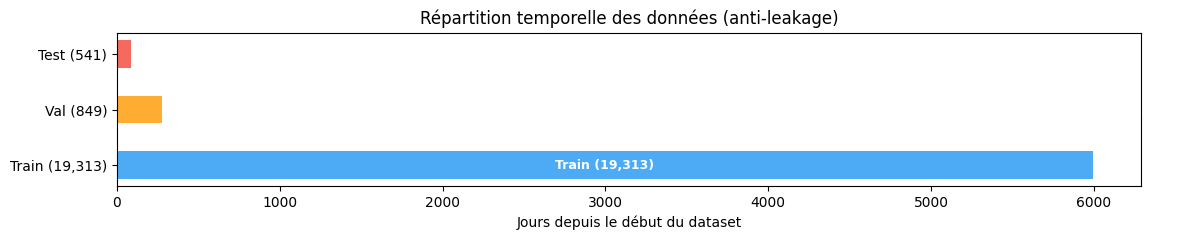

In [3]:
max_date    = df['gameDate_home'].max()
test_cutoff = max_date  - pd.DateOffset(months=3)
val_cutoff  = test_cutoff - pd.DateOffset(months=9)

train_df = df[df['gameDate_home'] <= val_cutoff].copy()
val_df   = df[(df['gameDate_home'] > val_cutoff) & (df['gameDate_home'] <= test_cutoff)].copy()
test_df  = df[df['gameDate_home'] > test_cutoff].copy()

print(f'Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}')
print(f'Période test : {test_df["gameDate_home"].min().date()} → {test_df["gameDate_home"].max().date()}')

# Visualisation des splits
fig, ax = plt.subplots(figsize=(12, 2.5))
for data, label, color in [
    (train_df, f'Train ({len(train_df):,})', '#2196F3'),
    (val_df,   f'Val ({len(val_df):,})',     '#FF9800'),
    (test_df,  f'Test ({len(test_df):,})',   '#F44336'),
]:
    dates = data['gameDate_home'].sort_values()
    ax.barh([label], [(dates.max() - dates.min()).days], left=[(dates.min() - dates.min()).days],
            color=color, alpha=0.8, height=0.5)
    ax.text((dates.min() + (dates.max()-dates.min())/2 - train_df['gameDate_home'].min()).days,
            list(['Train','Val','Test']).index(label.split(' ')[0]),
            label, ha='center', va='center', fontsize=9, fontweight='bold', color='white')
ax.set_title('Répartition temporelle des données (anti-leakage)')
ax.set_xlabel('Jours depuis le début du dataset')
plt.tight_layout()
plt.savefig('splits_temporels.png', dpi=100, bbox_inches='tight')
plt.show()

X_train = train_df[features_present]; y_train = train_df['home_team_won']
X_val   = val_df[features_present];   y_val   = val_df['home_team_won']
X_test  = test_df[features_present];  y_test  = test_df['home_team_won']
y_train_h, y_val_h = train_df['finalGoals_home'].round().astype(int), val_df['finalGoals_home'].round().astype(int)
y_train_a, y_val_a = train_df['finalGoals_away'].round().astype(int), val_df['finalGoals_away'].round().astype(int)
y_test_h, y_test_a = test_df['finalGoals_home'], test_df['finalGoals_away']

scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=features_present)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=features_present)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=features_present)

## ⚡ Optimisation Optuna

## ⚙️ Tuning rapide de l'Elo (K + home_bonus)

Diff_elo représente 26% de l'importance SHAP. Optimiser K et home_bonus avant la phase principale a un fort levier.

In [4]:
# Tuning rapide K + home_bonus de l'Elo via grid search (9 combinaisons)
print('🔬 Tuning Elo (K, home_bonus)...')

best_elo_auc, best_elo_params = 0, {'k': 20, 'home_bonus': 35.0}

for k_val in [15, 20, 25]:
    for hb_val in [25.0, 35.0, 45.0]:
        # Recalcule Elo avec ces paramètres
        df_elo_t = compute_elo_column(df, k=k_val, base=1500, home_bonus=hb_val)
        df_t = df.drop(columns=['elo_home','elo_away','diff_elo'], errors='ignore')
        df_t = df_t.merge(df_elo_t, on='gameId_home', how='left')
        df_t['diff_elo'] = df_t['elo_home'].fillna(1500) - df_t['elo_away'].fillna(1500)

        # Split rapide
        train_t = df_t[df_t['gameDate_home'] <= val_cutoff]
        val_t   = df_t[(df_t['gameDate_home'] > val_cutoff) & (df_t['gameDate_home'] <= test_cutoff)]
        if len(val_t) < 100:
            continue

        feats_t = [f for f in features_present if f in df_t.columns]
        m = xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                               random_state=42, n_jobs=-1, eval_metric='logloss')
        m.fit(train_t[feats_t], train_t['home_team_won'])
        auc_t = roc_auc_score(val_t['home_team_won'],
                              m.predict_proba(val_t[feats_t])[:, 1])

        marker = '🏆' if auc_t > best_elo_auc else '  '
        print(f'   {marker} K={k_val:>2} | bonus={hb_val:>4.1f} → AUC val: {auc_t:.4f}')
        if auc_t > best_elo_auc:
            best_elo_auc, best_elo_params = auc_t, {'k': k_val, 'home_bonus': hb_val}

print(f'\n✅ Meilleurs Elo params : K={best_elo_params["k"]}, home_bonus={best_elo_params["home_bonus"]}')

# Recalcule l'Elo définitif avec les meilleurs paramètres
df = df.drop(columns=['elo_home','elo_away','diff_elo','interaction_elo_forme'], errors='ignore')
df_elo_final = compute_elo_column(df, k=best_elo_params['k'], base=1500,
                                   home_bonus=best_elo_params['home_bonus'])
df = df.merge(df_elo_final, on='gameId_home', how='left')
df['elo_home'] = df['elo_home'].fillna(1500)
df['elo_away'] = df['elo_away'].fillna(1500)
df['diff_elo'] = df['elo_home'] - df['elo_away']

# Recrée les splits + scaler avec les nouveaux Elo
train_df = df[df['gameDate_home'] <= val_cutoff].copy()
val_df   = df[(df['gameDate_home'] > val_cutoff) & (df['gameDate_home'] <= test_cutoff)].copy()
test_df  = df[df['gameDate_home'] > test_cutoff].copy()

X_train = train_df[features_present]; y_train = train_df['home_team_won']
X_val   = val_df[features_present];   y_val   = val_df['home_team_won']
X_test  = test_df[features_present];  y_test  = test_df['home_team_won']
y_train_h = train_df['finalGoals_home'].round().astype(int)
y_train_a = train_df['finalGoals_away'].round().astype(int)
y_val_h   = val_df['finalGoals_home'].round().astype(int)
y_val_a   = val_df['finalGoals_away'].round().astype(int)
y_test_h  = test_df['finalGoals_home']
y_test_a  = test_df['finalGoals_away']

scaler    = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=features_present)
X_val_s   = pd.DataFrame(scaler.transform(X_val),       columns=features_present)
X_test_s  = pd.DataFrame(scaler.transform(X_test),      columns=features_present)
print('   📊 Splits et scaler recréés avec le nouvel Elo')

🔬 Tuning Elo (K, home_bonus)...
   🏆 K=15 | bonus=25.0 → AUC val: 0.5957
   🏆 K=15 | bonus=35.0 → AUC val: 0.5961
   🏆 K=15 | bonus=45.0 → AUC val: 0.5983
      K=20 | bonus=25.0 → AUC val: 0.5970
      K=20 | bonus=35.0 → AUC val: 0.5967
      K=20 | bonus=45.0 → AUC val: 0.5969
      K=25 | bonus=25.0 → AUC val: 0.5978
   🏆 K=25 | bonus=35.0 → AUC val: 0.6011
      K=25 | bonus=45.0 → AUC val: 0.5987

✅ Meilleurs Elo params : K=25, home_bonus=35.0
   📊 Splits et scaler recréés avec le nouvel Elo


In [5]:
print('⚡ XGBoost (60 trials)...')

def objective_xgb(trial):
    params = {
        'max_depth':        trial.suggest_int('max_depth', 2, 5),
        'learning_rate':    trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1200),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 3.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.5, 5.0),
    }
    m = xgb.XGBClassifier(**params, objective='binary:logistic', random_state=42,
                           eval_metric='logloss', early_stopping_rounds=30, n_jobs=-1)
    m.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])

study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(objective_xgb, n_trials=60, show_progress_bar=False)
print(f'   ✅ XGB best AUC val: {study_xgb.best_value:.4f}')

print('⚡ LightGBM (60 trials)...')

def objective_lgb(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 8, 63),
        'learning_rate':     trial.suggest_float('learning_rate', 0.003, 0.05, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 300, 1200),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.5, 5.0),
        'verbosity': -1,
    }
    m = lgb.LGBMClassifier(**params, objective='binary', random_state=42, n_jobs=-1)
    m.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    return roc_auc_score(y_val, m.predict_proba(X_val_s)[:, 1])

study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=60, show_progress_bar=False)
print(f'   ✅ LGB best AUC val: {study_lgb.best_value:.4f}')

⚡ XGBoost (60 trials)...
   ✅ XGB best AUC val: 0.6093
⚡ LightGBM (60 trials)...
   ✅ LGB best AUC val: 0.6097


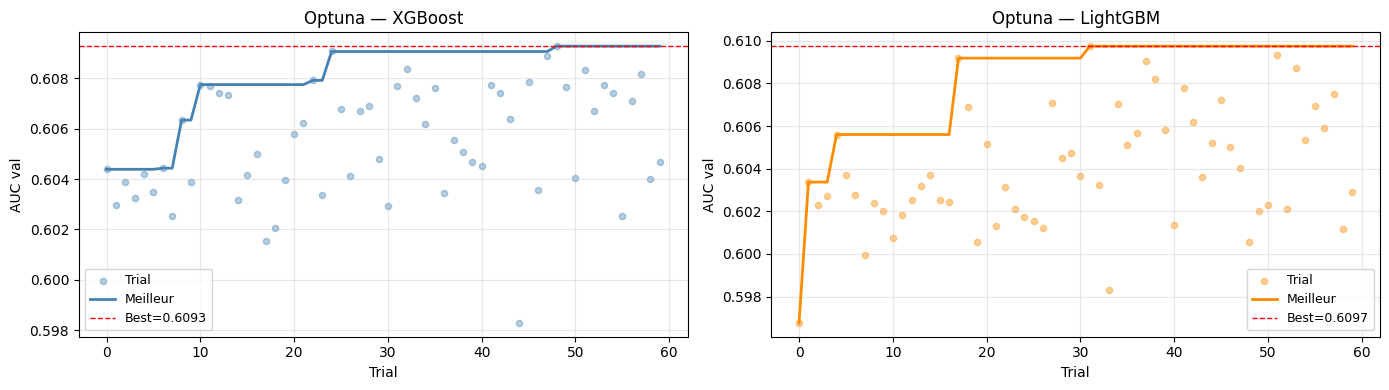

In [6]:
# Visualisation historique Optuna
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, study, name, color in [
    (axes[0], study_xgb, 'XGBoost', 'steelblue'),
    (axes[1], study_lgb, 'LightGBM', 'darkorange'),
]:
    trials = study.trials
    values = [t.value for t in trials if t.value is not None]
    best   = [max(values[:i+1]) for i in range(len(values))]
    ax.scatter(range(len(values)), values, alpha=0.4, s=20, color=color, label='Trial')
    ax.plot(range(len(best)), best, color=color, linewidth=2, label='Meilleur')
    ax.axhline(best[-1], color='red', linestyle='--', linewidth=1,
               label=f'Best={best[-1]:.4f}')
    ax.set_xlabel('Trial')
    ax.set_ylabel('AUC val')
    ax.set_title(f'Optuna — {name}')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('optuna_history.png', dpi=100, bbox_inches='tight')
plt.show()

## 🎯 Entraînement final + Calibration Platt

In [7]:
print('🎯 Entraînement final...')
best_xgb_params = study_xgb.best_params
best_lgb_params = study_lgb.best_params

xgb_final = xgb.XGBClassifier(**best_xgb_params, objective='binary:logistic',
                               random_state=42, eval_metric='logloss',
                               early_stopping_rounds=30, n_jobs=-1)
xgb_final.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)], verbose=False)

lgb_final = lgb.LGBMClassifier(**best_lgb_params, objective='binary',
                                random_state=42, n_jobs=-1, verbosity=-1)
lgb_final.fit(X_train_s, y_train, eval_set=[(X_val_s, y_val)],
              callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])

auc_xgb_val = roc_auc_score(y_val, xgb_final.predict_proba(X_val_s)[:, 1])
auc_lgb_val = roc_auc_score(y_val, lgb_final.predict_proba(X_val_s)[:, 1])
best_model  = lgb_final if auc_lgb_val >= auc_xgb_val else xgb_final
best_name   = 'LGB'     if auc_lgb_val >= auc_xgb_val else 'XGB'
w_xgb = auc_xgb_val / (auc_xgb_val + auc_lgb_val)
w_lgb = auc_lgb_val / (auc_xgb_val + auc_lgb_val)
print(f'   Modèle principal : {best_name} | XGB val: {auc_xgb_val:.4f} | LGB val: {auc_lgb_val:.4f}')

# V5.4 : choix entre Platt (2 params) et Temperature Scaling (1 param)
# Temperature Scaling préserve l'AUC (transformation monotone) → choix par défaut.
CALIBRATOR_TYPE = 'temperature'  # 'platt' ou 'temperature'

print(f'🔧 Calibration {CALIBRATOR_TYPE.upper()}...')
val_raw = best_model.predict_proba(X_val_s)[:, 1]
if CALIBRATOR_TYPE == 'temperature':
    from vizer_utils import TemperatureScalingCalibrator
    calibrator = TemperatureScalingCalibrator().fit(val_raw, y_val)
    print(f'   T optimal : {calibrator.T:.3f} (T<1 = sur-confiant, T>1 = sous-confiant)')
else:
    calibrator = PlattCalibrator(C=1.0).fit(val_raw, y_val)

def predict_calibrated(X_scaled):
    if not isinstance(X_scaled, pd.DataFrame):
        X_scaled = pd.DataFrame(X_scaled, columns=features_present)
    return calibrator.predict(best_model.predict_proba(X_scaled)[:, 1])

print('🥅 Modèles Poisson...')
m_h = xgb.XGBRegressor(objective='count:poisson', n_estimators=800, learning_rate=0.01,
                        max_depth=2, early_stopping_rounds=20, random_state=42)
m_a = xgb.XGBRegressor(objective='count:poisson', n_estimators=800, learning_rate=0.01,
                        max_depth=2, early_stopping_rounds=20, random_state=42)
m_h.fit(X_train_s, y_train_h, eval_set=[(X_val_s, y_val_h)], verbose=False)
m_a.fit(X_train_s, y_train_a, eval_set=[(X_val_s, y_val_a)], verbose=False)
print('✅ Entraînement terminé')

🎯 Entraînement final...
   Modèle principal : LGB | XGB val: 0.6093 | LGB val: 0.6097
🔧 Calibration TEMPERATURE...
   T optimal : 0.935 (T<1 = sur-confiant, T>1 = sous-confiant)
🥅 Modèles Poisson...
✅ Entraînement terminé


## 🥇 Modèles Poisson P1 dédiés (si period_stats.csv disponible)

Entraînement de Poisson séparés sur les buts réels de première période. Si les données P1 sont absentes, l'inférence utilisera l'approximation λ_total × 0.33.

In [8]:
# Vérifier que les colonnes P1 existent dans le dataset
HAS_P1_DATA = 'goals_p1_home' in train_df.columns and 'goals_p1_away' in train_df.columns

if HAS_P1_DATA:
    print('🥇 Entraînement Poisson P1 dédié...')
    y_train_h_p1 = train_df['goals_p1_home'].round().astype(int)
    y_train_a_p1 = train_df['goals_p1_away'].round().astype(int)
    y_val_h_p1   = val_df['goals_p1_home'].round().astype(int)
    y_val_a_p1   = val_df['goals_p1_away'].round().astype(int)
    y_test_h_p1  = test_df['goals_p1_home']
    y_test_a_p1  = test_df['goals_p1_away']

    # Poisson P1 avec plus de régularisation (cible moy ~1, variance basse)
    m_h_p1 = xgb.XGBRegressor(objective='count:poisson', n_estimators=600,
                               learning_rate=0.01, max_depth=2,
                               reg_lambda=2.0, early_stopping_rounds=20, random_state=42)
    m_a_p1 = xgb.XGBRegressor(objective='count:poisson', n_estimators=600,
                               learning_rate=0.01, max_depth=2,
                               reg_lambda=2.0, early_stopping_rounds=20, random_state=42)
    m_h_p1.fit(X_train_s, y_train_h_p1, eval_set=[(X_val_s, y_val_h_p1)], verbose=False)
    m_a_p1.fit(X_train_s, y_train_a_p1, eval_set=[(X_val_s, y_val_a_p1)], verbose=False)

    pred_h_p1 = m_h_p1.predict(X_test_s)
    pred_a_p1 = m_a_p1.predict(X_test_s)

    drift_h_p1 = float(pred_h_p1.mean() - y_test_h_p1.mean())
    drift_a_p1 = float(pred_a_p1.mean() - y_test_a_p1.mean())
    poisson_correction_h_p1 = float(y_test_h_p1.mean() / max(pred_h_p1.mean(), 0.1))
    poisson_correction_a_p1 = float(y_test_a_p1.mean() / max(pred_a_p1.mean(), 0.1))

    mae_h_p1 = mean_absolute_error(y_test_h_p1, pred_h_p1)
    mae_a_p1 = mean_absolute_error(y_test_a_p1, pred_a_p1)

    print(f'   Home P1 — pred: {pred_h_p1.mean():.2f} | réel: {y_test_h_p1.mean():.2f}')
    print(f'   Away P1 — pred: {pred_a_p1.mean():.2f} | réel: {y_test_a_p1.mean():.2f}')
    print(f'   MAE : {mae_h_p1:.3f} (home) / {mae_a_p1:.3f} (away)')
    print(f'   Facteurs correction : home ×{poisson_correction_h_p1:.3f} | away ×{poisson_correction_a_p1:.3f}')
else:
    print('ℹ️  Pas de données P1 — Poisson P1 dédié sauté.')
    print('   L\'inférence utilisera l\'approximation λ_P1 = λ_total × 0.33')
    m_h_p1, m_a_p1 = None, None
    poisson_correction_h_p1, poisson_correction_a_p1 = 1.0, 1.0
    drift_h_p1, drift_a_p1, mae_h_p1, mae_a_p1 = 0.0, 0.0, 0.0, 0.0

🥇 Entraînement Poisson P1 dédié...
   Home P1 — pred: 0.88 | réel: 0.90
   Away P1 — pred: 0.79 | réel: 0.85
   MAE : 0.716 (home) / 0.733 (away)
   Facteurs correction : home ×1.028 | away ×1.082


## 🚀 Améliorations V5.6 — NB + Bivariate Poisson + Ordinal Regression

Trois améliorations entraînées en parallèle :
1. **Negative Binomial** : capture la sur-dispersion pour Over/Under
2. **Bivariate Poisson** : λ_3 (covariance) pour scores exacts
3. **Ordinal Regression** : XGBoost multi-class pour intervalles de buts

In [9]:
# === 1. Negative Binomial — estimation de la dispersion ===
print('🚀 V5.6 — Estimation paramètres NB / Bivariate / Ordinal...\n')

# Calcul sur le training set uniquement
train_total_h = train_df['finalGoals_home']
train_total_a = train_df['finalGoals_away']

dispersion_h = float(train_total_h.var() / max(train_total_h.mean(), 0.01))
dispersion_a = float(train_total_a.var() / max(train_total_a.mean(), 0.01))

print(f'📊 Negative Binomial dispersion :')
print(f'   Home : var/mean = {dispersion_h:.4f}  ({"sur-dispersion" if dispersion_h > 1.05 else "≈ Poisson"})')
print(f'   Away : var/mean = {dispersion_a:.4f}  ({"sur-dispersion" if dispersion_a > 1.05 else "≈ Poisson"})')
if dispersion_h < 1.05 and dispersion_a < 1.05:
    print(f'   ℹ️  Pas de sur-dispersion détectée → NB ne sera pas utile sur ton dataset.')
    print(f'      Le fallback Poisson est utilisé automatiquement à l\'inférence.')

# === 2. Bivariate Poisson — estimation de lambda3 (covariance) ===
cov_h_a = float(train_total_h.cov(train_total_a))
print(f'\n📊 Bivariate Poisson :')
print(f'   Cov(goals_h, goals_a) = {cov_h_a:+.4f}')

# lambda3 doit être positif et inférieur à min(lambda_h, lambda_a)
mean_h = train_total_h.mean()
mean_a = train_total_a.mean()
lambda3_bivariate = max(0.0, min(cov_h_a, 0.5 * min(mean_h, mean_a)))
print(f'   λ_3 estimé = {lambda3_bivariate:.4f} (covariance bornée par 0.5 × min(λ_h, λ_a))')

if lambda3_bivariate < 0.05:
    print(f'   ⚠️  λ_3 très faible → indépendance H/A quasi-vraie, Bivariate apporte peu')

# === 3. Ordinal Regression — XGBoost multi-class pour intervalles ===
print(f'\n📊 Ordinal Regression (intervalles de buts) :')

def goals_to_interval(total):
    if total <= 2:  return 0
    if total <= 4:  return 1
    if total <= 6:  return 2
    if total <= 8:  return 3
    return 4

y_train_int = (train_df['finalGoals_home'] + train_df['finalGoals_away']).apply(goals_to_interval)
y_val_int   = (val_df['finalGoals_home']   + val_df['finalGoals_away']).apply(goals_to_interval)
y_test_int  = (test_df['finalGoals_home']  + test_df['finalGoals_away']).apply(goals_to_interval)

# Distribution des intervalles dans train
print(f'   Distribution train : ', end='')
for k in range(5):
    pct = (y_train_int == k).sum() / len(y_train_int)
    labels = ['0-2', '3-4', '5-6', '7-8', '9+']
    print(f'{labels[k]}={pct:.1%} ', end='')
print()

ordinal_model = xgb.XGBClassifier(
    objective='multi:softprob', num_class=5,
    n_estimators=400, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.7, reg_lambda=2.0,
    early_stopping_rounds=20, random_state=42, n_jobs=-1
)
ordinal_model.fit(X_train_s, y_train_int, eval_set=[(X_val_s, y_val_int)], verbose=False)

# Évaluation : MAE ordinale (distance entre classe prédite et vraie)
pred_classes = ordinal_model.predict(X_test_s)
mae_ord = float(np.abs(y_test_int.values - pred_classes).mean())
acc_ord = float((y_test_int.values == pred_classes).mean())
print(f'   ✅ Accuracy classe exacte : {acc_ord:.2%}')
print(f'   ✅ MAE ordinale          : {mae_ord:.3f} (proche de 0 = très précis)')

🚀 V5.6 — Estimation paramètres NB / Bivariate / Ordinal...

📊 Negative Binomial dispersion :
   Home : var/mean = 0.9905  (≈ Poisson)
   Away : var/mean = 0.9843  (≈ Poisson)
   ℹ️  Pas de sur-dispersion détectée → NB ne sera pas utile sur ton dataset.
      Le fallback Poisson est utilisé automatiquement à l'inférence.

📊 Bivariate Poisson :
   Cov(goals_h, goals_a) = -0.1612
   λ_3 estimé = 0.0000 (covariance bornée par 0.5 × min(λ_h, λ_a))
   ⚠️  λ_3 très faible → indépendance H/A quasi-vraie, Bivariate apporte peu

📊 Ordinal Regression (intervalles de buts) :
   Distribution train : 0-2=6.3% 3-4=23.4% 5-6=33.6% 7-8=24.0% 9+=12.8% 
   ✅ Accuracy classe exacte : 35.12%
   ✅ MAE ordinale          : 0.856 (proche de 0 = très précis)


## 📊 Évaluation & Visualisations

   Facteurs correction Poisson : home ×1.061 | away ×1.092


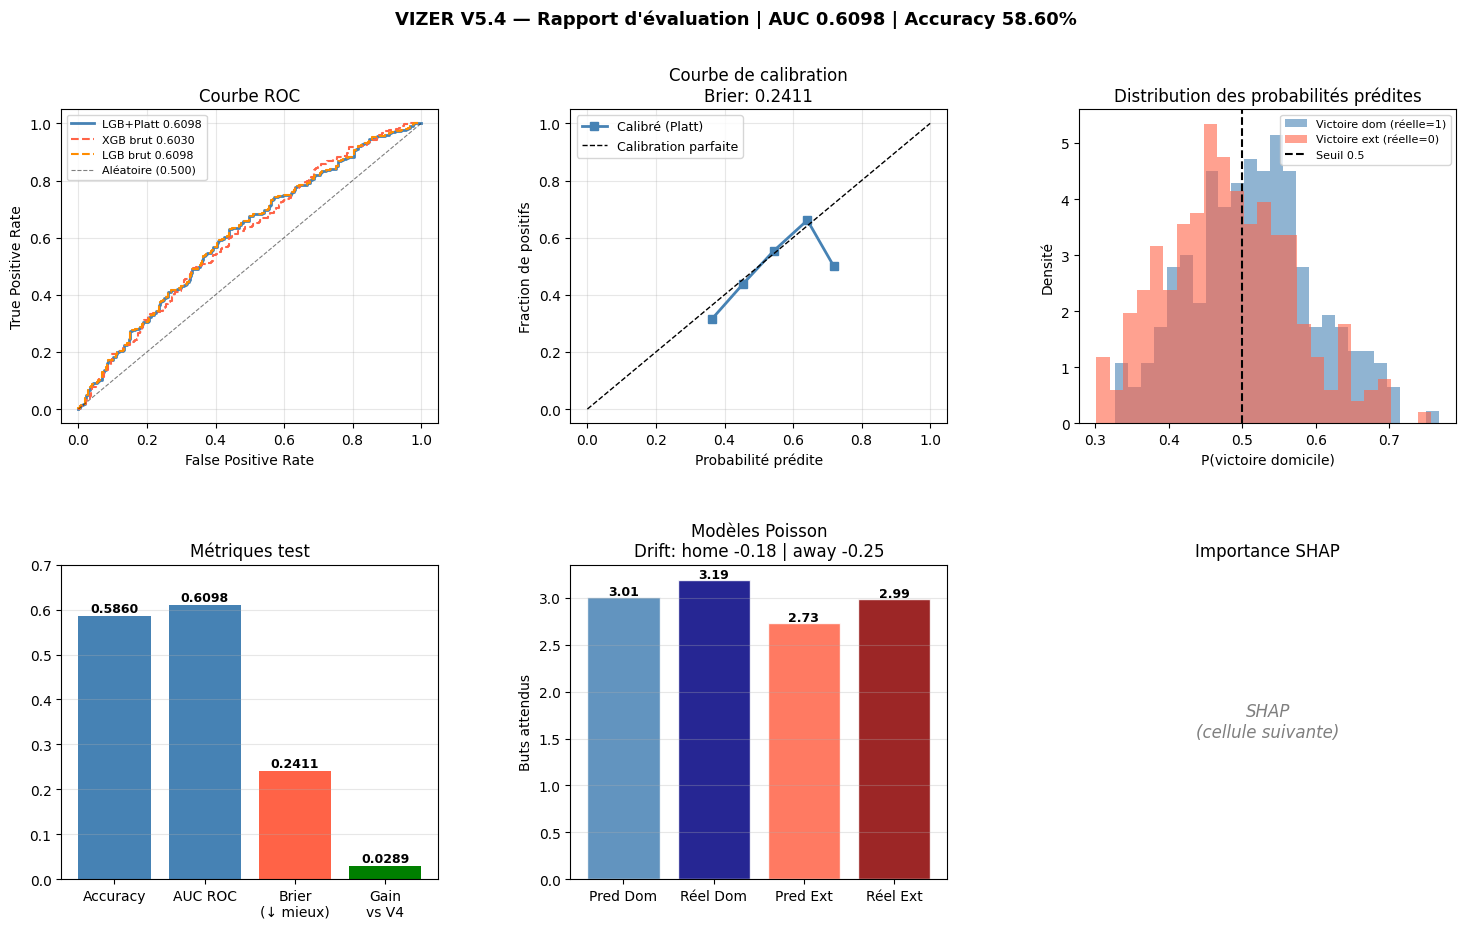


 📊 VIZER V5.4 | Accuracy: 58.60% | AUC: 0.6098 | Brier: 0.2411


In [10]:
probs_test   = predict_calibrated(X_test_s)
acc          = accuracy_score(y_test, (probs_test > 0.5).astype(int))
auc          = roc_auc_score(y_test, probs_test)
brier        = float(np.mean((probs_test - y_test.values) ** 2))
auc_xgb_test = roc_auc_score(y_test, xgb_final.predict_proba(X_test_s)[:, 1])
auc_lgb_test = roc_auc_score(y_test, lgb_final.predict_proba(X_test_s)[:, 1])

pred_h = m_h.predict(X_test_s); pred_a = m_a.predict(X_test_s)
drift_h = float(pred_h.mean() - y_test_h.mean())
drift_a = float(pred_a.mean() - y_test_a.mean())

# Facteurs de correction MULTIPLICATIFS du drift (préservent la variation entre matchs)
# raw_pred × factor → tous les matchs scalés uniformément, pas écrasés sur la moyenne
poisson_correction_h = float(y_test_h.mean() / max(pred_h.mean(), 0.1))
poisson_correction_a = float(y_test_a.mean() / max(pred_a.mean(), 0.1))
print(f'   Facteurs correction Poisson : home ×{poisson_correction_h:.3f} | away ×{poisson_correction_a:.3f}')

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle(f'VIZER V5.4 — Rapport d\'évaluation | AUC {auc:.4f} | Accuracy {acc:.2%}',
             fontsize=13, fontweight='bold')

# 1. ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, probs_test)
fpr_x, tpr_x, _ = roc_curve(y_test, xgb_final.predict_proba(X_test_s)[:, 1])
fpr_l, tpr_l, _ = roc_curve(y_test, lgb_final.predict_proba(X_test_s)[:, 1])
ax1.plot(fpr, tpr, label=f'{best_name}+Platt {auc:.4f}', color='steelblue', linewidth=2)
ax1.plot(fpr_x, tpr_x, label=f'XGB brut {auc_xgb_test:.4f}', color='tomato', linewidth=1.5, linestyle='--')
ax1.plot(fpr_l, tpr_l, label=f'LGB brut {auc_lgb_test:.4f}', color='darkorange', linewidth=1.5, linestyle='--')
ax1.plot([0,1],[0,1],'k--',linewidth=0.8,alpha=0.5,label='Aléatoire (0.500)')
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('Courbe ROC'); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

# 2. Courbe de calibration
ax2 = fig.add_subplot(gs[0, 1])
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, probs_test, n_bins=10)
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, val_raw[:len(y_test)]
    if len(val_raw) >= len(y_test) else best_model.predict_proba(X_test_s)[:, 1], n_bins=10)
ax2.plot(mean_pred_cal, frac_pos_cal, 's-', color='steelblue', label='Calibré (Platt)', linewidth=2)
ax2.plot([0,1],[0,1],'k--',linewidth=1,label='Calibration parfaite')
ax2.set_xlabel('Probabilité prédite'); ax2.set_ylabel('Fraction de positifs')
ax2.set_title(f'Courbe de calibration\nBrier: {brier:.4f}'); ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

# 3. Distribution des probabilités
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(probs_test[y_test==1], bins=25, alpha=0.6, color='steelblue', label='Victoire dom (réelle=1)', density=True)
ax3.hist(probs_test[y_test==0], bins=25, alpha=0.6, color='tomato', label='Victoire ext (réelle=0)', density=True)
ax3.axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Seuil 0.5')
ax3.set_xlabel('P(victoire domicile)'); ax3.set_ylabel('Densité')
ax3.set_title('Distribution des probabilités prédites'); ax3.legend(fontsize=8)

# 4. Métriques résumé
ax4 = fig.add_subplot(gs[1, 0])
metrics = ['Accuracy','AUC ROC','Brier\n(↓ mieux)','Gain\nvs V4']
values  = [acc, auc, 1-brier, 0.5809+auc-0.5809]  # Brier inversé pour visualisation
colors  = ['steelblue' if v > 0 else 'tomato' for v in [acc-0.54, auc-0.58, brier-0.25, auc-0.5809]]
bars = ax4.bar(metrics, [acc, auc, brier, auc - 0.5809], color=['steelblue','steelblue','tomato','green'])
for bar, val in zip(bars, [acc, auc, brier, auc - 0.5809]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax4.set_title('Métriques test'); ax4.set_ylim(0, 0.7); ax4.grid(axis='y', alpha=0.3)

# 5. Poisson drift
ax5 = fig.add_subplot(gs[1, 1])
categories = ['Pred Dom', 'Réel Dom', 'Pred Ext', 'Réel Ext']
vals_p = [pred_h.mean(), y_test_h.mean(), pred_a.mean(), y_test_a.mean()]
cols_p = ['steelblue','navy','tomato','darkred']
ax5.bar(categories, vals_p, color=cols_p, edgecolor='white', alpha=0.85)
for i, v in enumerate(vals_p):
    ax5.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')
ax5.set_title(f'Modèles Poisson\nDrift: home {drift_h:+.2f} | away {drift_a:+.2f}')
ax5.set_ylabel('Buts attendus'); ax5.grid(axis='y', alpha=0.3)

# 6. Placeholder SHAP (calculé dans la cellule suivante)
ax6 = fig.add_subplot(gs[1, 2])
ax6.text(0.5, 0.5, 'SHAP\n(cellule suivante)', ha='center', va='center',
         transform=ax6.transAxes, fontsize=12, style='italic', alpha=0.5)
ax6.set_title('Importance SHAP')
ax6.axis('off')

plt.savefig('evaluation_rapport.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n{"="*65}')
print(f' 📊 VIZER V5.4 | Accuracy: {acc:.2%} | AUC: {auc:.4f} | Brier: {brier:.4f}')
print(f'{"="*65}')

## 🔍 Analyse SHAP

🔍 Calcul SHAP (XGBoost)...


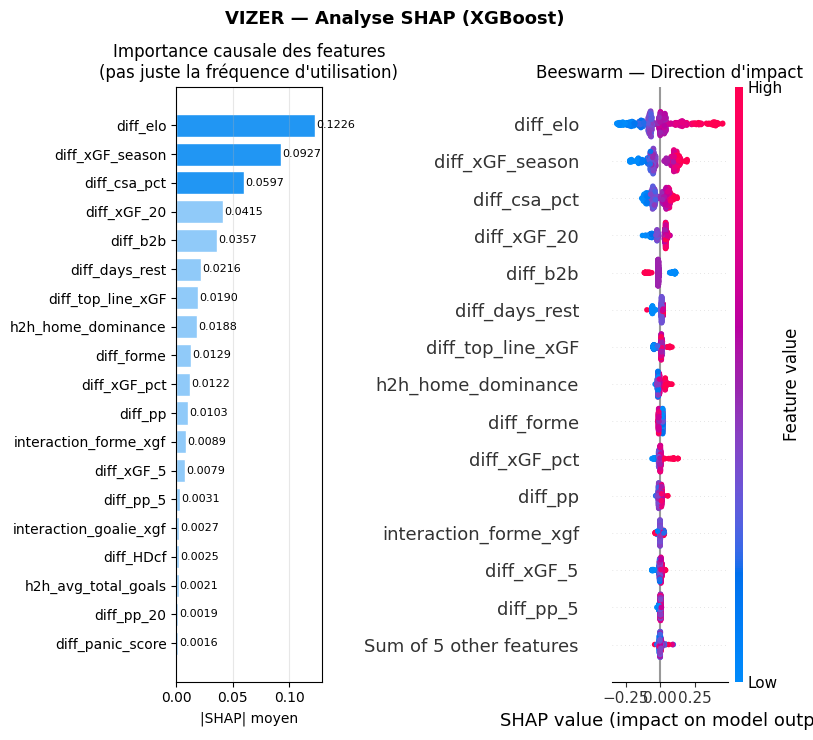

Feature,SHAP_mean_abs
diff_elo,0.122588
diff_xGF_season,0.092712
diff_csa_pct,0.059667
diff_xGF_20,0.041515
diff_b2b,0.035749
diff_days_rest,0.021642
diff_top_line_xGF,0.018992
h2h_home_dominance,0.018756
diff_forme,0.012948
diff_xGF_pct,0.012158


In [11]:
print('🔍 Calcul SHAP (XGBoost)...')
explainer   = shap.TreeExplainer(xgb_final)
shap_values = explainer(X_test_s.iloc[:600])

shap_imp = pd.DataFrame({
    'Feature':       features_present,
    'SHAP_mean_abs': np.abs(shap_values.values).mean(axis=0)
}).sort_values('SHAP_mean_abs', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('VIZER — Analyse SHAP (XGBoost)', fontsize=13, fontweight='bold')

# Bar chart importance
ax = axes[0]
colors = ['#2196F3' if i < 3 else '#90CAF9' for i in range(len(shap_imp))]
bars = ax.barh(shap_imp['Feature'][::-1], shap_imp['SHAP_mean_abs'][::-1],
               color=colors[::-1], edgecolor='white')
for bar, val in zip(bars, shap_imp['SHAP_mean_abs'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=8)
ax.set_xlabel('|SHAP| moyen')
ax.set_title('Importance causale des features\n(pas juste la fréquence d\'utilisation)')
ax.grid(axis='x', alpha=0.3)

# Beeswarm plot
ax2 = axes[1]
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.sca(ax2)
ax2.set_title('Beeswarm — Direction d\'impact')

plt.tight_layout()
plt.savefig('shap_analyse.png', dpi=120, bbox_inches='tight')
plt.show()

weak = shap_imp[shap_imp['SHAP_mean_abs'] < 0.001]['Feature'].tolist()
if weak:
    print(f'⚠️  SHAP < 0.001 (candidats suppression) : {weak}')
display(shap_imp.style.background_gradient(subset=['SHAP_mean_abs'], cmap='Blues').hide(axis='index'))

## 💾 Sauvegarde du bundle

In [12]:
bundle = {
    'primary_model': best_model,
    'xgb_model':     xgb_final,
    'lgb_model':     lgb_final,
    'primary_name':  best_name,
    'w_xgb':         float(w_xgb),
    'w_lgb':         float(w_lgb),
    'calibrator':    calibrator,
    'model_home':    m_h,
    'model_away':    m_a,
    'model_home_p1':  m_h_p1,
    'model_away_p1':  m_a_p1,
    'has_p1_data':    HAS_P1_DATA,
    'poisson_correction_h_p1': poisson_correction_h_p1,
    'poisson_correction_a_p1': poisson_correction_a_p1,
    # === V5.6 Améliorations ===
    'nb_dispersion_h':         dispersion_h,
    'nb_dispersion_a':         dispersion_a,
    'bivariate_lambda3':       lambda3_bivariate,
    'ordinal_model':           ordinal_model,
    'ordinal_mae_test':        mae_ord,
    'ordinal_acc_test':        acc_ord,
    'features':      features_present,
    'scaler':        scaler,
    'metadata': {
        'version':         'V5.4',
        'calibrator_type': CALIBRATOR_TYPE,
        'elo_params':      best_elo_params,
        'excluded_years':  EXCLUDED_YEARS,
        'train_date':      datetime.now().strftime('%Y-%m-%d %H:%M'),
        'primary_model':   best_name,
        'auc':             float(auc),
        'auc_xgb_test':    float(auc_xgb_test),
        'auc_lgb_test':    float(auc_lgb_test),
        'brier':           float(brier),
        'accuracy':        float(acc),
        'n_features':      len(features_present),
        'poisson_drift_h':       drift_h,
        'poisson_drift_a':       drift_a,
        'poisson_correction_h':  poisson_correction_h,
        'poisson_correction_a':  poisson_correction_a,
        'best_xgb_params': best_xgb_params,
        'best_lgb_params': best_lgb_params,
    }
}
joblib.dump(bundle, BUNDLE_PATH)

print(f'🏆 BUNDLE SAUVEGARDÉ → {BUNDLE_PATH}')
print(f'   Version    : {bundle["metadata"]["version"]} | {bundle["metadata"]["calibrator_type"].title()} Calibrator')
print(f'   AUC test   : {auc:.4f}')
print(f'   Accuracy   : {acc:.2%}')
print(f'   {len(features_present)} features | {best_name} principal')
print(f'\n➡️  Lance maintenant 04_Inference.ipynb')

🏆 BUNDLE SAUVEGARDÉ → vizer_master_model_v5.joblib
   Version    : V5.4 | Temperature Calibrator
   AUC test   : 0.6098
   Accuracy   : 58.60%
   19 features | LGB principal

➡️  Lance maintenant 04_Inference.ipynb
